In [1]:
# Project 2: Exploratory Data Analysis
# DecodeLabs Data Analytics Internship

# Project 2: Exploratory Data Analysis

## Introduction

This project focuses on exploring a cleaned e-commerce dataset to identify patterns, trends, distributions, and potential outliers.

The analysis is being conducted as part of the DecodeLabs Data Analytics Internship.

## Objectives

- Calculate descriptive statistics
- Explore patterns and distributions
- Identify trends and outliers
- Examine relationships between variables
- Summarize key findings and observations

In [3]:
# Import Pandas to load, manipulate and analyze the dataset
import pandas as pd

In [4]:
# Load the cleaned dataset into a DataFrame
# A DataFrame is a digital spreadsheet or table that organizes your data into rows and columns, much like an Excel sheet.
df = pd.read_excel("ecommerce_cleaned_dataset.xlsx")

In [5]:
# Display the first five rows to get an initial view of the dataset
df.head()

,Order_ID,Date,Customer_ID,Product,Quantity,Unit_Price,Shipping_Address,Payment_Method,Order_Status,Tracking_Number,Items_In_Cart,Coupon_Code,Referral_Source,Total_Price
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [6]:
# Check the number of rows and columns in the dataset
df.shape

(1200, 14)

In [7]:
# Display the column names to identify the variables available for analysis
df.columns

Index(['Order_ID', 'Date', 'Customer_ID', 'Product', 'Quantity', 'Unit_Price',
       'Shipping_Address', 'Payment_Method', 'Order_Status', 'Tracking_Number',
       'Items_In_Cart', 'Coupon_Code', 'Referral_Source', 'Total_Price'],
      dtype='object')

In [8]:
# Check the data type of each column to ensure variables are stored appropriately for analysis
df.dtypes

Order_ID                    object
Date                datetime64[ns]
Customer_ID                 object
Product                     object
Quantity                     int64
Unit_Price                 float64
Shipping_Address            object
Payment_Method              object
Order_Status                object
Tracking_Number             object
Items_In_Cart                int64
Coupon_Code                 object
Referral_Source             object
Total_Price                float64
dtype: object

In [9]:
# Display a summary of the dataset including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          1200 non-null   object        
 1   Date              1200 non-null   datetime64[ns]
 2   Customer_ID       1200 non-null   object        
 3   Product           1200 non-null   object        
 4   Quantity          1200 non-null   int64         
 5   Unit_Price        1200 non-null   float64       
 6   Shipping_Address  1200 non-null   object        
 7   Payment_Method    1200 non-null   object        
 8   Order_Status      1200 non-null   object        
 9   Tracking_Number   1200 non-null   object        
 10  Items_In_Cart     1200 non-null   int64         
 11  Coupon_Code       1200 non-null   object        
 12  Referral_Source   1200 non-null   object        
 13  Total_Price       1200 non-null   float64       
dtypes: datetime64[ns](1), fl

In [10]:
# Calculate the number of observations for each numerical variable
df[['Quantity', 'Unit_Price', 'Items_In_Cart', 'Total_Price']].count()

Quantity         1200
Unit_Price       1200
Items_In_Cart    1200
Total_Price      1200
dtype: int64

In [11]:
# Calculate the average value of each numerical variable
df[['Quantity', 'Unit_Price', 'Items_In_Cart', 'Total_Price']].mean()

Quantity            2.945833
Unit_Price        356.412750
Items_In_Cart       5.485000
Total_Price      1053.968300
dtype: float64

In [12]:
# Calculate the median value of each numerical variable
df[['Quantity', 'Unit_Price', 'Items_In_Cart', 'Total_Price']].median()

Quantity           3.000
Unit_Price       364.210
Items_In_Cart      5.000
Total_Price      823.615
dtype: float64

In [13]:
# Generate descriptive statistics for the numerical variables
df[['Quantity', 'Unit_Price', 'Items_In_Cart', 'Total_Price']].describe()

,Quantity,Unit_Price,Items_In_Cart,Total_Price
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [14]:
# Calculate the first quartile (Q1) and third quartile (Q3) for Total_Price
Q1 = df['Total_Price'].quantile(0.25)
Q3 = df['Total_Price'].quantile(0.75)

Q1, Q3

(410.52, 1578.475)

In [15]:
# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

IQR

1167.955

In [16]:
# Calculate the lower and upper boundaries for identifying potential outliers
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

lower_bound, upper_bound

(-1341.4125, 3330.4075)

In [17]:
# Identify orders with Total_Price values above the upper outlier boundary
outliers = df[df['Total_Price'] > upper_bound]

outliers

,Order_ID,Date,Customer_ID,Product,Quantity,Unit_Price,Shipping_Address,Payment_Method,Order_Status,Tracking_Number,Items_In_Cart,Coupon_Code,Referral_Source,Total_Price
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NO COUPON,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NO COUPON,Facebook,3390.95


In [18]:
# Identify orders with Total_Price values below the lower outlier boundary
low_outliers = df[df['Total_Price'] < lower_bound]

low_outliers

,Order_ID,Date,Customer_ID,Product,Quantity,Unit_Price,Shipping_Address,Payment_Method,Order_Status,Tracking_Number,Items_In_Cart,Coupon_Code,Referral_Source,Total_Price


In [19]:
# Count the number of potential low outliers
low_outliers.shape[0]

0

In [20]:
# Import Seaborn for creating statistical visualizations
import seaborn as sns

# Import Matplotlib for creating and displaying charts
import matplotlib.pyplot as plt

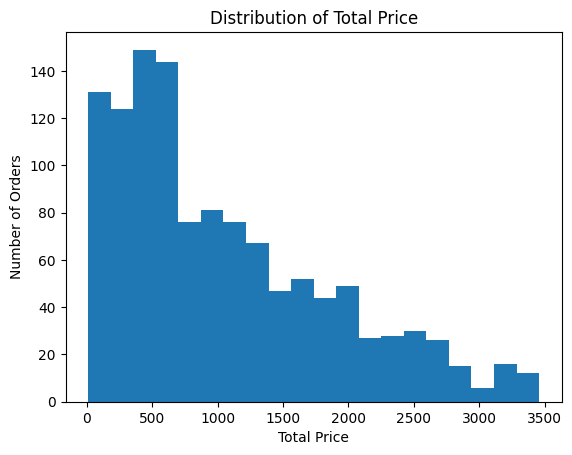

In [21]:
# Plot the distribution of Total_Price
plt.hist(df['Total_Price'], bins=20)

# Add a title and labels
plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Number of Orders')

# Display the chart
plt.show()

In [22]:
# Count the exact number of orders in each order status
df['Total_Price'].value_counts()

Total_Price
211.14     2
635.90     2
367.34     2
410.52     2
2517.36    2
          ..
538.68     1
640.88     1
2119.65    1
269.65     1
2242.32    1
Name: count, Length: 1195, dtype: int64

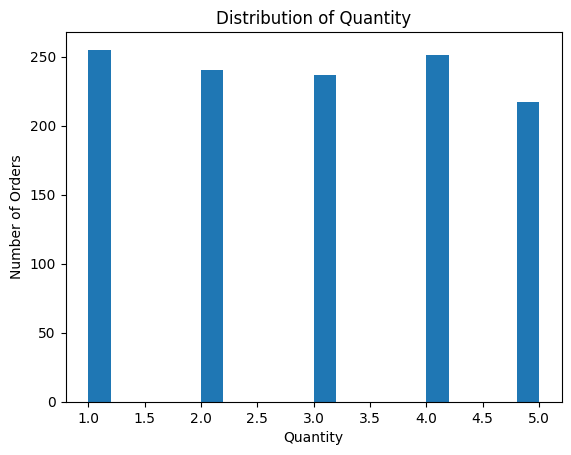

In [23]:
# Plot the distribution of Quantity
plt.hist(df['Quantity'], bins=20)

# Add a title and labels
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Number of Orders')

# Display the chart
plt.show()

In [24]:
# Count the exact number of orders in each order status
df['Quantity'].value_counts()

Quantity
1    255
4    251
2    240
3    237
5    217
Name: count, dtype: int64

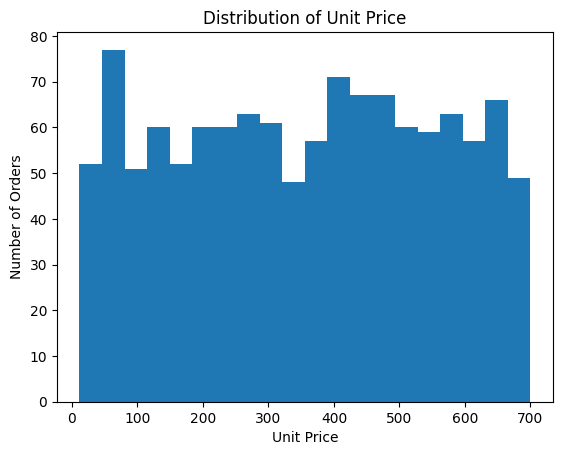

In [25]:
# Plot the distribution of Unit Price
plt.hist(df['Unit_Price'], bins=20)

# Add a title and labels
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Number of Orders')

# Display the chart
plt.show()

In [26]:
# Count the exact number of orders in each order status
df['Unit_Price'].value_counts()

Unit_Price
183.67    2
127.18    2
629.34    2
228.91    2
133.39    2
         ..
423.93    1
53.93     1
427.06    1
287.13    1
560.58    1
Name: count, Length: 1193, dtype: int64

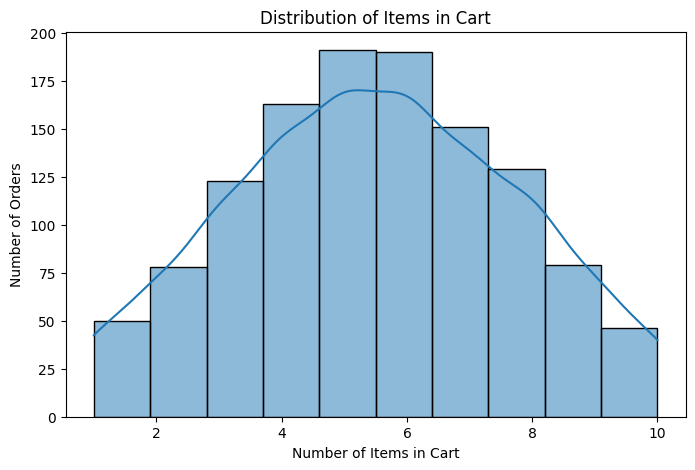

In [27]:
# Create a histogram to visualize the distribution of the number of items in customers' carts
plt.figure(figsize=(8, 5))

# Plot the frequency of different cart sizes and add a density curve
sns.histplot(data=df, x='Items_In_Cart', bins=10, kde=True)

# Add a title and labels to make the chart easy to understand
plt.title('Distribution of Items in Cart')
plt.xlabel('Number of Items in Cart')
plt.ylabel('Number of Orders')

# Display the chart
plt.show()

In [28]:
# Count the exact number of orders in each order status
df['Items_In_Cart'].value_counts()

Items_In_Cart
5     191
6     190
4     163
7     151
8     129
3     123
9      79
2      78
1      50
10     46
Name: count, dtype: int64

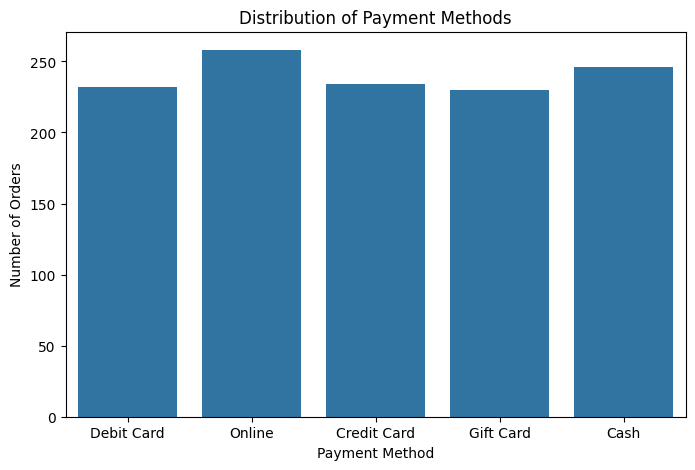

In [29]:
# Create a count plot to visualize the number of orders for each payment method
plt.figure(figsize=(8, 5))

# Count how many orders were made using each payment method
sns.countplot(data=df, x='Payment_Method')

# Add a title and labels to make the chart easy to understand
plt.title('Distribution of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')

# Display the chart
plt.show()

In [30]:
# Count the exact number of orders in each order status
df['Payment_Method'].value_counts()

Payment_Method
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

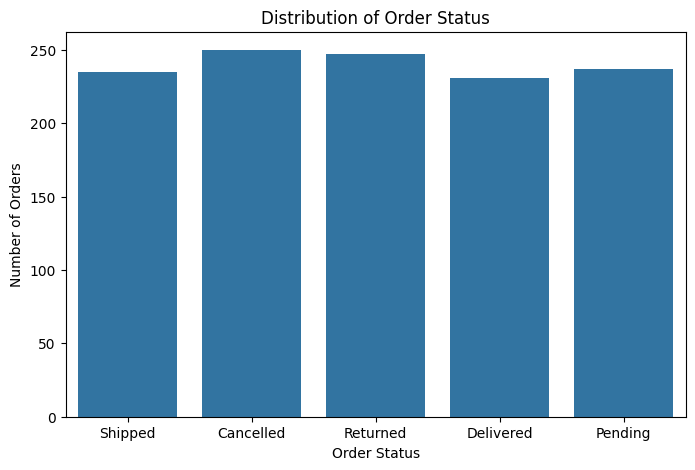

In [31]:
# Create a count plot to visualize the number of orders for each order status
plt.figure(figsize=(8, 5))

# Count how many orders fall under each order status
sns.countplot(data=df, x='Order_Status')

# Add a title and labels to make the chart easy to understand
plt.title('Distribution of Order Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')

# Display the chart
plt.show()

In [32]:
# Count the exact number of orders in each order status
df['Order_Status'].value_counts()

Order_Status
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

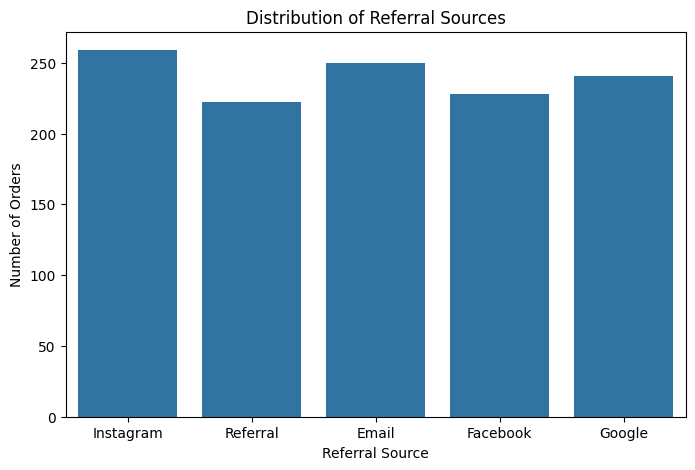

In [33]:
# Create a count plot to visualize the number of orders from each referral source
plt.figure(figsize=(8, 5))

# Count how many orders came from each referral source
sns.countplot(data=df, x='Referral_Source')

# Add a title and labels to make the chart easy to understand
plt.title('Distribution of Referral Sources')
plt.xlabel('Referral Source')
plt.ylabel('Number of Orders')

# Display the chart
plt.show()

In [34]:
# Count the exact number of orders in each order status
df['Referral_Source'].value_counts()

Referral_Source
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

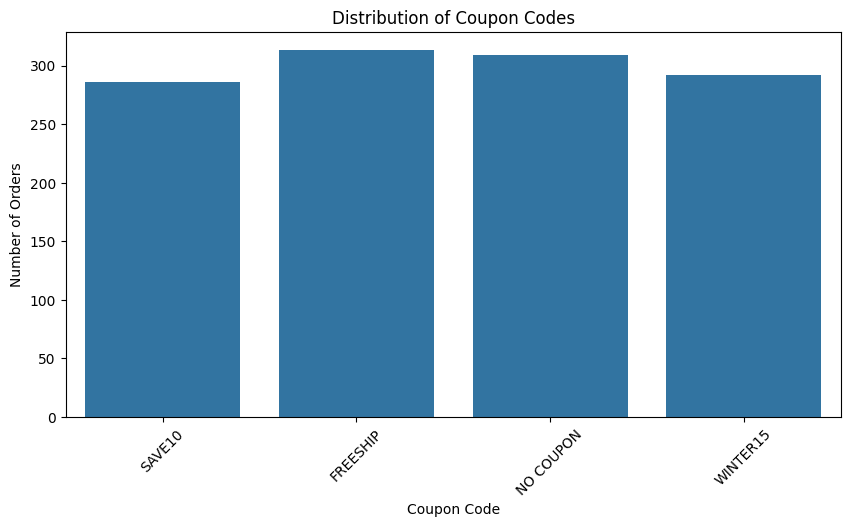

In [35]:
# Create a count plot to visualize how frequently each coupon code appears
plt.figure(figsize=(10, 5))

# Count the number of orders associated with each coupon code
sns.countplot(data=df, x='Coupon_Code')

# Add a title and labels to make the chart easy to understand
plt.title('Distribution of Coupon Codes')
plt.xlabel('Coupon Code')
plt.ylabel('Number of Orders')

# Rotate the labels slightly if they are crowded
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [36]:
# Count the exact number of orders in each order status
df['Coupon_Code'].value_counts()

Coupon_Code
FREESHIP     313
NO COUPON    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

In [37]:
# Count the number of unique products in the dataset
df['Product'].nunique()

7

In [38]:
# Count how many orders were placed for each product
df['Product'].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

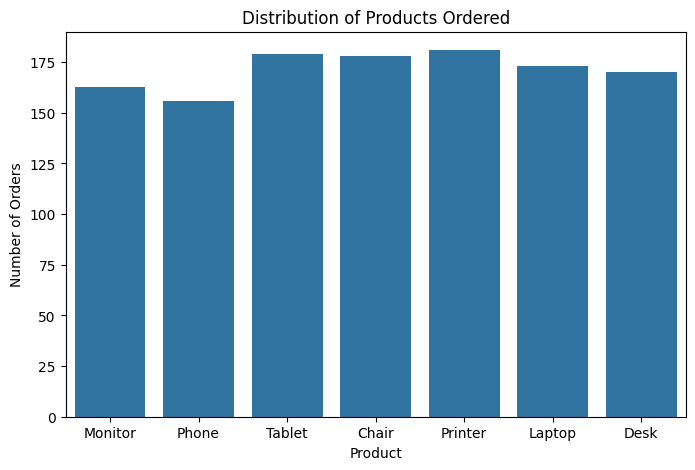

In [39]:
# Create a bar chart to visualize the number of orders for each product
plt.figure(figsize=(8, 5))

# Count and display how many orders were recorded for each product
sns.countplot(data=df, x='Product')

# Add a title and labels to explain the chart
plt.title('Distribution of Products Ordered')
plt.xlabel('Product')
plt.ylabel('Number of Orders')

# Display the chart
plt.show()

In [40]:
# Group the orders by month and count the number of orders in each month
monthly_orders = df.groupby(df['Date'].dt.to_period('M')).size()

# Display the number of orders for each month
monthly_orders

Date
2023-01    47
2023-02    37
2023-03    43
2023-04    31
2023-05    49
2023-06    45
2023-07    44
2023-08    51
2023-09    29
2023-10    47
2023-11    41
2023-12    46
2024-01    32
2024-02    32
2024-03    36
2024-04    50
2024-05    34
2024-06    53
2024-07    43
2024-08    28
2024-09    44
2024-10    31
2024-11    35
2024-12    41
2025-01    27
2025-02    37
2025-03    49
2025-04    32
2025-05    37
2025-06    49
Freq: M, dtype: int64

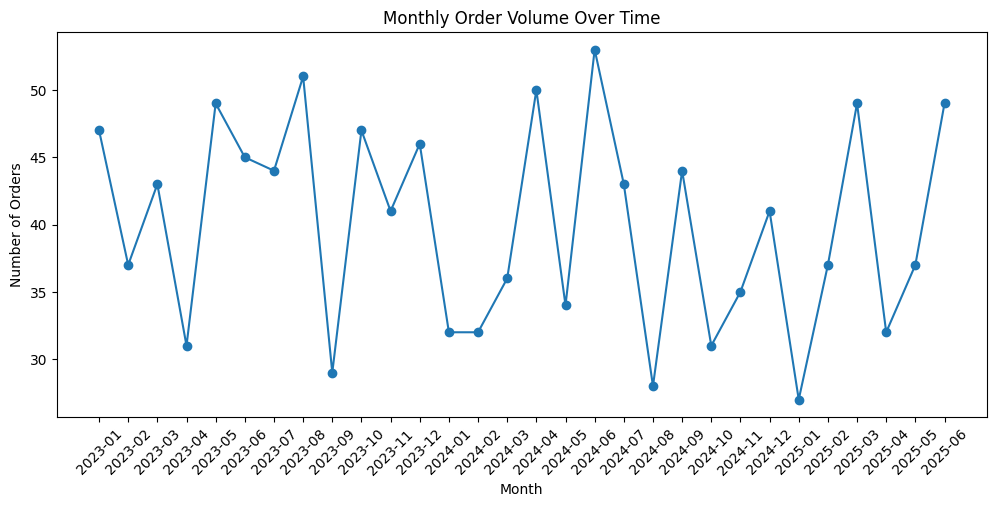

In [41]:
# Create a line chart to visualize how the number of orders changes over time
plt.figure(figsize=(12, 5))

# Plot the monthly order counts
plt.plot(monthly_orders.index.astype(str), monthly_orders.values, marker='o')

# Add a title and labels to explain the chart
plt.title('Monthly Order Volume Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

# Rotate the month labels so they are easier to read
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [42]:
# Calculate the total sales revenue generated in each month
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total_Price'].sum()

# Display the total sales for each month
monthly_sales

Date
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: Total_Price, dtype: float64

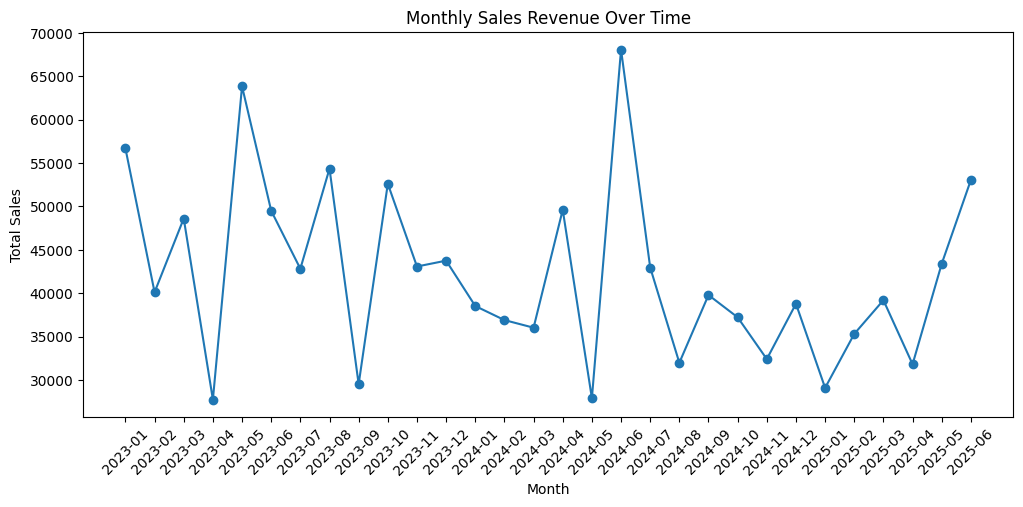

In [43]:
# Create a line chart to visualize how total sales change from month to month
plt.figure(figsize=(12, 5))

# Plot the monthly sales values
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')

# Add a title and labels to explain the chart
plt.title('Monthly Sales Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')

# Rotate the month labels so they are easier to read
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [44]:
# Calculate the average value of an order for each month
monthly_aov = df.groupby(df['Date'].dt.to_period('M'))['Total_Price'].mean()

# Display the average order value for each month
monthly_aov

Date
2023-01    1206.079787
2023-02    1084.261081
2023-03    1130.450465
2023-04     895.216452
2023-05    1302.792653
2023-06    1100.004222
2023-07     973.196818
2023-08    1065.728235
2023-09    1018.161034
2023-10    1119.315957
2023-11    1050.723659
2023-12     951.189783
2024-01    1204.002500
2024-02    1153.424062
2024-03    1000.858333
2024-04     992.262800
2024-05     820.856176
2024-06    1284.312075
2024-07     999.162326
2024-08    1142.538214
2024-09     904.431364
2024-10    1200.870000
2024-11     926.107429
2024-12     945.994390
2025-01    1077.755556
2025-02     954.528378
2025-03     800.013469
2025-04     994.412500
2025-05    1172.882162
2025-06    1082.600000
Freq: M, Name: Total_Price, dtype: float64

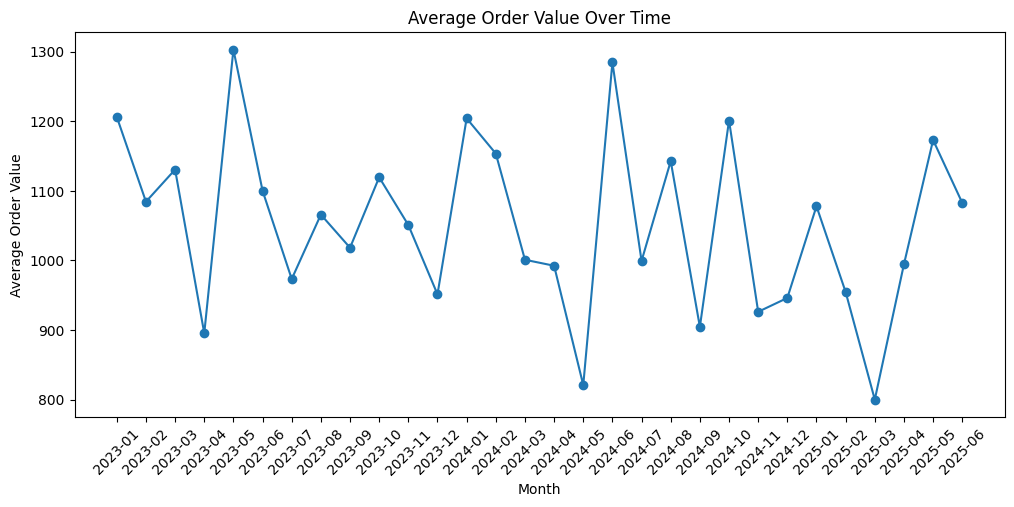

In [45]:
# Create a line chart to visualize the average order value over time
plt.figure(figsize=(12, 5))

# Plot the monthly average order value
plt.plot(monthly_aov.index.astype(str), monthly_aov.values, marker='o')

# Add a title and labels to explain the chart
plt.title('Average Order Value Over Time')
plt.xlabel('Month')
plt.ylabel('Average Order Value')

# Rotate the month labels to make them easier to read
plt.xticks(rotation=45)

# Display the chart
plt.show()

In [46]:
# Calculate the correlation between the numerical variables in the dataset
correlation_matrix = df[['Quantity', 'Unit_Price', 'Items_In_Cart', 'Total_Price']].corr()

# Display the correlation matrix
correlation_matrix

,Quantity,Unit_Price,Items_In_Cart,Total_Price
Quantity,1.000000,0.014553,0.650061,0.615251
Unit_Price,0.014553,1.000000,0.000602,0.717081
Items_In_Cart,0.650061,0.000602,1.000000,0.392540
Total_Price,0.615251,0.717081,0.392540,1.000000


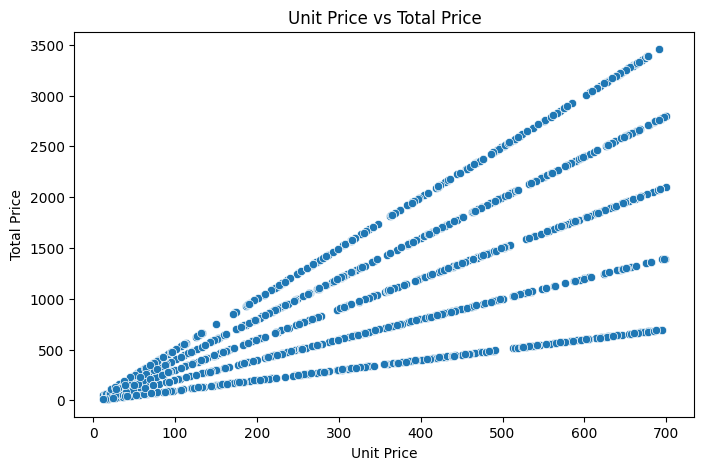

In [47]:
# Create a scatter plot to visualize the relationship between Unit_Price and Total_Price
plt.figure(figsize=(8, 5))

# Plot each order as a point using Unit_Price and Total_Price
sns.scatterplot(data=df, x='Unit_Price', y='Total_Price')

# Add a title and labels to explain the chart
plt.title('Unit Price vs Total Price')
plt.xlabel('Unit Price')
plt.ylabel('Total Price')

# Display the chart
plt.show()

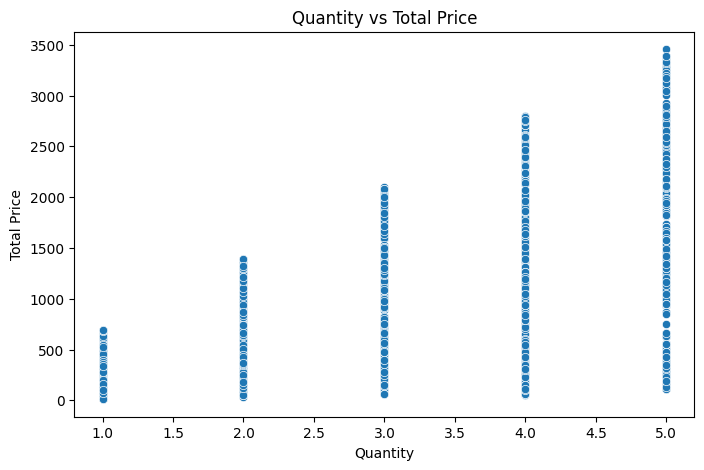

In [48]:
# Create a scatter plot to visualize the relationship between Quantity and Total_Price
plt.figure(figsize=(8, 5))

# Plot each order as a point using Quantity and Total_Price
sns.scatterplot(data=df, x='Quantity', y='Total_Price')

# Add a title and labels to explain the chart
plt.title('Quantity vs Total Price')
plt.xlabel('Quantity')
plt.ylabel('Total Price')

# Display the chart
plt.show()

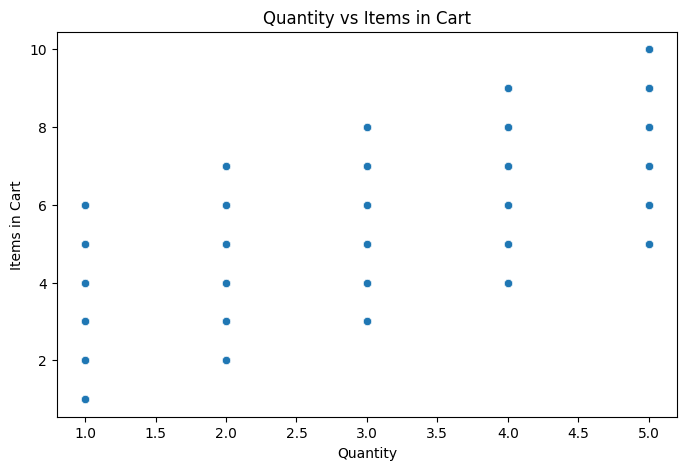

In [49]:
# Create a scatter plot to visualize the relationship between Quantity and Items_In_Cart
plt.figure(figsize=(8, 5))

# Plot each order as a point using Quantity and Items_In_Cart
sns.scatterplot(data=df, x='Quantity', y='Items_In_Cart')

# Add a title and labels to explain the chart
plt.title('Quantity vs Items in Cart')
plt.xlabel('Quantity')
plt.ylabel('Items in Cart')

# Display the chart
plt.show()

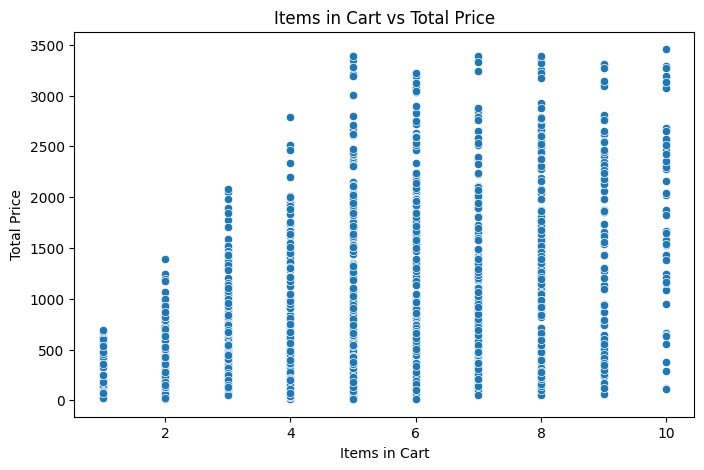

In [50]:
# Create a scatter plot to visualize the relationship between Items_In_Cart and Total_Price
plt.figure(figsize=(8, 5))

# Plot each order as a point using Items_In_Cart and Total_Price
sns.scatterplot(data=df, x='Items_In_Cart', y='Total_Price')

# Add a title and labels to explain the chart
plt.title('Items in Cart vs Total Price')
plt.xlabel('Items in Cart')
plt.ylabel('Total Price')

# Display the chart
plt.show()

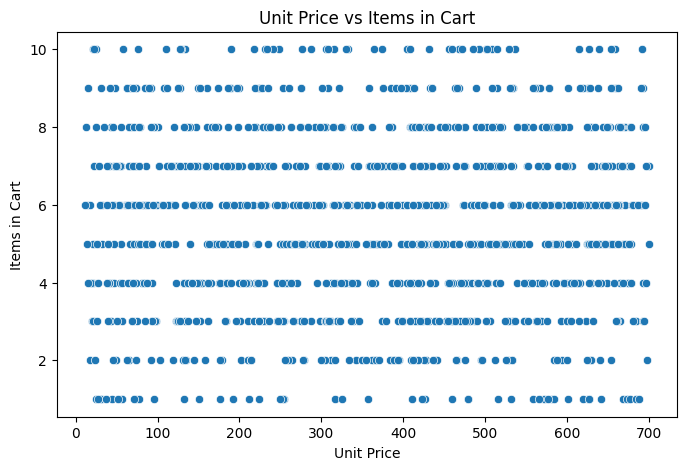

In [51]:
# Create a scatter plot to visualize the relationship between Unit_Price and Items_In_Cart
plt.figure(figsize=(8, 5))

# Plot each order based on its unit price and number of items in the cart
sns.scatterplot(data=df, x='Unit_Price', y='Items_In_Cart')

# Add a title and labels to explain the chart
plt.title('Unit Price vs Items in Cart')
plt.xlabel('Unit Price')
plt.ylabel('Items in Cart')

# Display the chart
plt.show()

In [56]:
# Calculate the total revenue generated by each product
product_order_value = df.groupby('Product')['Total_Price'].sum().sort_values(ascending=False)

# Display the products from highest to lowest revenue
product_order_value

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: Total_Price, dtype: float64

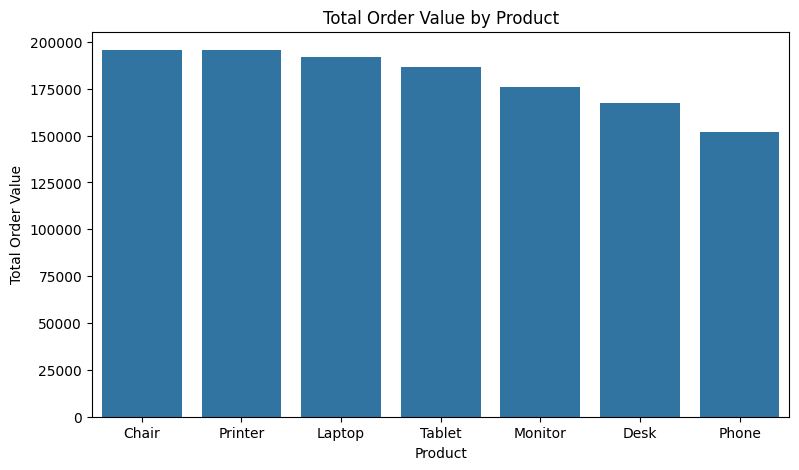

In [57]:
# Create a bar chart to compare total order value across products
plt.figure(figsize=(9, 5))

# Plot the total order value for each product
sns.barplot(x=product_order_value.index, y=product_order_value.values)

# Add a title and labels to explain the chart
plt.title('Total Order Value by Product')
plt.xlabel('Product')
plt.ylabel('Total Order Value')

# Display the chart
plt.show()

In [54]:
# Calculate the total revenue generated by each order status
status_revenue = df.groupby('Order_Status')['Total_Price'].sum().sort_values(ascending=False)

# Display the revenue for each order status from highest to lowest
status_revenue

Order_Status
Cancelled    276396.21
Pending      256328.15
Shipped      246159.58
Returned     243277.70
Delivered    242600.32
Name: Total_Price, dtype: float64

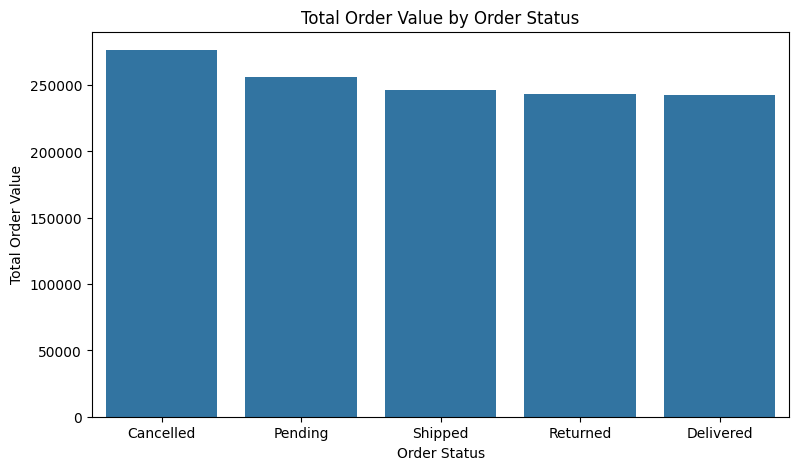

In [58]:
# Visualize the total order value for each order status
plt.figure(figsize=(9, 5))

# Create a bar chart showing the total order value for each status
sns.barplot(x=status_revenue.index, y=status_revenue.values)

# Add a title and labels to explain the chart
plt.title('Total Order Value by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Total Order Value')

# Display the chart
plt.show()

In [59]:
# Calculate the total order value for each referral source
referral_order_value = df.groupby('Referral_Source')['Total_Price'].sum().sort_values(ascending=False)

# Display the total order value for each referral source
referral_order_value

Referral_Source
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: Total_Price, dtype: float64

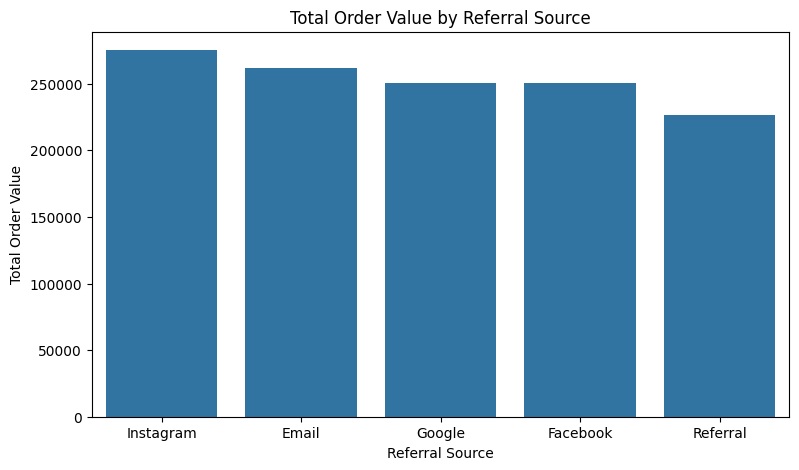

In [60]:
# Visualize the total order value associated with each referral source
plt.figure(figsize=(9, 5))

# Create a bar chart comparing total order value across referral sources
sns.barplot(x=referral_order_value.index, y=referral_order_value.values)

# Add a title and labels to explain the chart
plt.title('Total Order Value by Referral Source')
plt.xlabel('Referral Source')
plt.ylabel('Total Order Value')

# Display the chart
plt.show()